# Exploratory Data Analysis (EDA) - Analisis Sentimen Ulasan Chess.com
Proyek ini bertujuan untuk membongkar tren ulasan, komposisi sentimen multi-class (Positif, Netral, Negatif), serta melakukan eksplorasi teks terhadap fenomena penting dalam 10 tahun terakhir.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Mengatur tema visualisasi agar konsisten dan modern
sns.set_theme(style="whitegrid")

print("Memuat dataset catur hasil preprocessing...")
df = pd.read_csv("D:\\MY PORTO\\DATA SCIENTIEST\\ANALISIS SENTIMEN\\sentiment-chesscom-id\\data\\processed\\ulasan_chess_cleaned.csv")

# Mengisi baris kosong jika ada teks yang hilang total saat preprocessing
df['komentar_bersih'] = df['komentar_bersih'].fillna("")

# Menampilkan informasi ringkas dimensi dan tipe data
print(f"Total data yang dimuat: {df.shape[0]} baris, {df.shape[1]} kolom.")
df.head()

Memuat dataset catur hasil preprocessing...
Total data yang dimuat: 23065 baris, 7 kolom.


,id,username,komentar,country,rate,waktu,komentar_bersih
0,828855b6-3b67-4c0a-bc0a-c588d9da0783,Erik . .,folk,ID,5,2026-05-30 02:52:06,folk
1,15002568-e2b3-40d3-9668-772fd9f6e1d7,Wira Ardiansyah,mantap lah pokoknya,ID,5,2026-05-30 01:20:14,mantap pokoknya
2,d1813ffb-c2f6-4bf7-8fac-c424fd2b0e8a,Alvino,membantu mengasah otak,ID,5,2026-05-29 19:47:37,membantu mengasah otak
3,0f278580-161b-44e2-9baa-5c3395f62284,Pian ?,"jangan asal banned akun orang, cek perangkat t...",ID,3,2026-05-29 18:31:06,banned akun cek perangkat tambahan gw ga pake ...
4,a15a4afa-25d0-4fb2-a15f-bfb6893fa67e,water,Do you miss us? No.,ID,5,2026-05-29 12:37:17,do you miss us no


## 1. Distribusi Rating Bintang dan Komposisi Sentimen
Kita akan melihat seberapa seimbang sebaran data antara rating bintang asli (1-5) dengan skema label 3 kelas yang kita terapkan (Negatif, Netral, Positif).

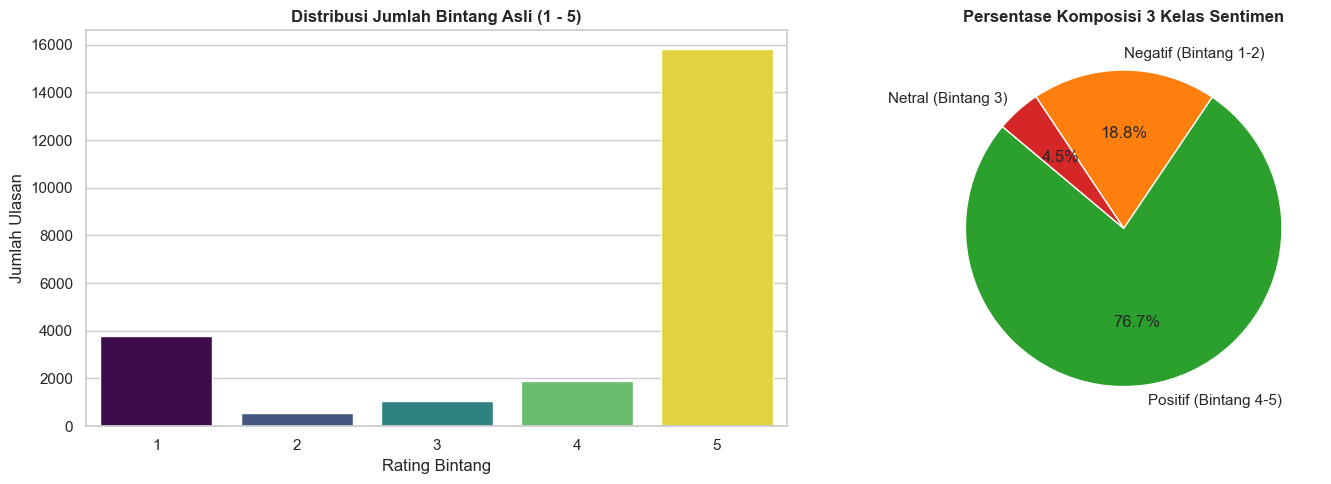

<Figure size 640x480 with 0 Axes>

In [14]:
# Fungsi pembantu untuk label visualisasi agar grafik mudah dibaca manusia
def fungsi_label(rate):
    if rate >= 4: return "Positif (Bintang 4-5)"
    elif rate == 3: return "Netral (Bintang 3)"
    else: return "Negatif (Bintang 1-2)"

df['kategori_sentimen'] = df['rate'].apply(fungsi_label)

# Setup kanvas grafik: 1 baris, 2 kolom berdampingan
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Grafik 1: Countplot rating bintang asli
sns.countplot(data=df, x='rate', ax=ax[0], hue='rate', palette='viridis', legend=False)
ax[0].set_title('Distribusi Jumlah Bintang Asli (1 - 5)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Rating Bintang')
ax[0].set_ylabel('Jumlah Ulasan')

# Grafik 2: Pie Chart komposisi 3 kelas sentimen
sebaran = df['kategori_sentimen'].value_counts()
ax[1].pie(sebaran, labels=sebaran.index, autopct='%1.1f%%', startangle=140, 
        colors=['#2ca02c', '#ff7f0e', '#d62728'])
ax[1].set_title('Persentase Komposisi 3 Kelas Sentimen', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
plt.savefig("../reports/figures/eda_sentimen_chesscom.png", dpi=300)   

## 2. Analisis Tren Waktu & Jejak Digital Fenomena 2021
Kita akan membedah fluktuasi bulanan khusus pada tahun 2021 untuk membuktikan lonjakan ulasan negatif secara spesifik pada periode terjadinya drama pemblokiran akun.

[SUKSES] Grafik tren 2021 berhasil diekspor ke: '../reports/figures/eda_tren_sentimen_2021.png'


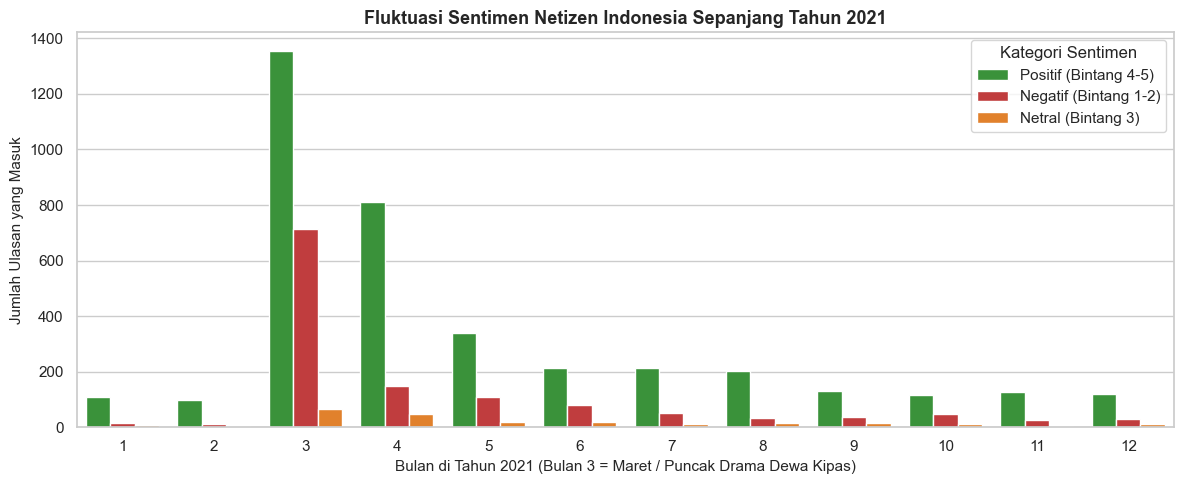

In [15]:
# Ekstraksi komponen waktu
df['waktu'] = pd.to_datetime(df['waktu'])
df['bulan'] = df['waktu'].dt.month
df['tahun'] = df['waktu'].dt.year

# Filter khusus untuk melihat pergerakan ulasan sepanjang tahun 2021
df_2021 = df[df['tahun'] == 2021].copy()

# =========================================================================
# Definisikan warna aslinya menggunakan Dictionary
# =========================================================================
kamus_warna = {
    "Positif (Bintang 4-5)": "#2ca02c",  # Hijau profesional
    "Netral (Bintang 3)": "#ff7f0e",     # Oranye
    "Negatif (Bintang 1-2)": "#d62728"   # Merah
}

plt.figure(figsize=(12, 5))

# Masukkan kamus_warna ke dalam parameter palette
sns.countplot(data=df_2021, x='bulan', hue='kategori_sentimen', palette=kamus_warna)

plt.title('Fluktuasi Sentimen Netizen Indonesia Sepanjang Tahun 2021', fontsize=13, fontweight='bold')
plt.xlabel('Bulan di Tahun 2021 (Bulan 3 = Maret / Puncak Drama Dewa Kipas)', fontsize=11)
plt.ylabel('Jumlah Ulasan yang Masuk', fontsize=11)
plt.legend(title='Kategori Sentimen')
plt.tight_layout()

# Sekalian kita simpan gambarnya ke folder figures seperti request-mu sebelumnya
jalur_tren_2021 = "../reports/figures/eda_tren_sentimen_2021.png"
plt.savefig(jalur_tren_2021, dpi=300, bbox_inches='tight')
print(f"[SUKSES] Grafik tren 2021 berhasil diekspor ke: '{jalur_tren_2021}'")

plt.show()

## 3. Ekstraksi Kata Keluhan Terbanyak pada Sentimen Negatif
Untuk memahami akar masalah dari ulasan buruk, kita akan mengekstrak ulasan bintang 1 dan 2, lalu menghitung 15 kata bersih yang paling sering diucapkan oleh netizen.

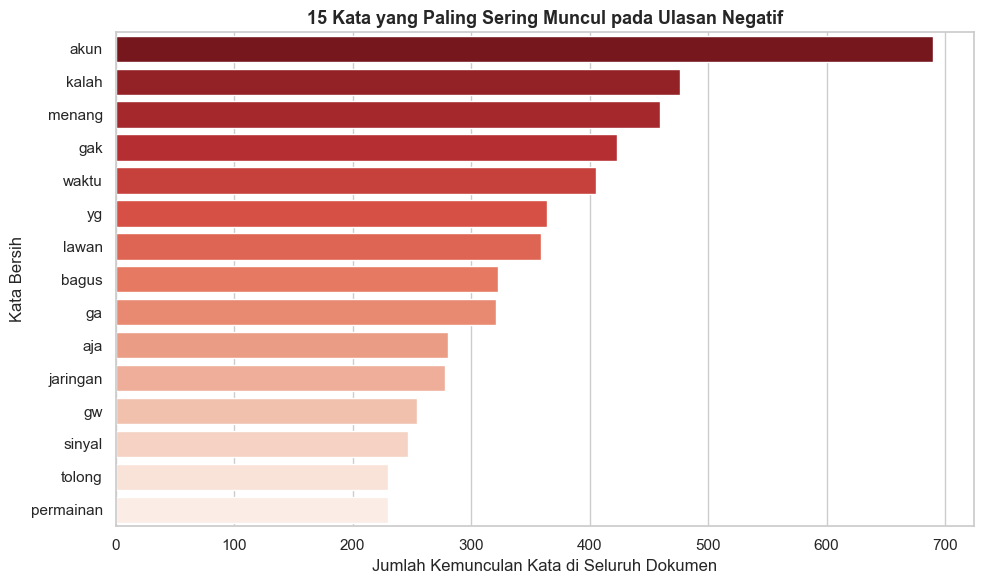

<Figure size 640x480 with 0 Axes>

In [16]:
# 1. Filter ulasan yang masuk kategori Negatif
komentar_negatif = df[df['rate'] <= 2]['komentar_bersih'].dropna()

# 2. Satukan seluruh baris kalimat menjadi satu teks raksasa, lalu pecah menjadi token kata
gabungan_kata_negatif = " ".join(komentar_negatif).split()

# 3. Hitung frekuensi kemunculan setiap kata menggunakan fungsi Counter
hitung_frekuensi = Counter(gabungan_kata_negatif)

# 4. Ubah 15 kata teratas menjadi DataFrame baru agar mudah di-plot
df_kata_populer = pd.DataFrame(hitung_frekuensi.most_common(15), columns=['Kata', 'Frekuensi'])

# 5. Gambar grafik batang horizontal
plt.figure(figsize=(10, 6))
sns.barplot(data=df_kata_populer, x='Frekuensi', y='Kata', hue='Kata', palette='Reds_r', legend=False)
plt.title('15 Kata yang Paling Sering Muncul pada Ulasan Negatif', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Kemunculan Kata di Seluruh Dokumen')
plt.ylabel('Kata Bersih')
plt.tight_layout()
plt.show()
plt.savefig("../reports/figures/eda_kata_negatif.png", dpi=300)

## 4. Visualisasi WordCloud Sentimen Positif vs Negatif
Kita akan menghasilkan awan kata untuk melihat secara intuitif kata apa saja yang paling mendominasi pada ulasan positif (Bintang 4-5) dan ulasan negatif (Bintang 1-2). Semakin besar ukuran kata, semakin sering kata tersebut diucapkan netizen.

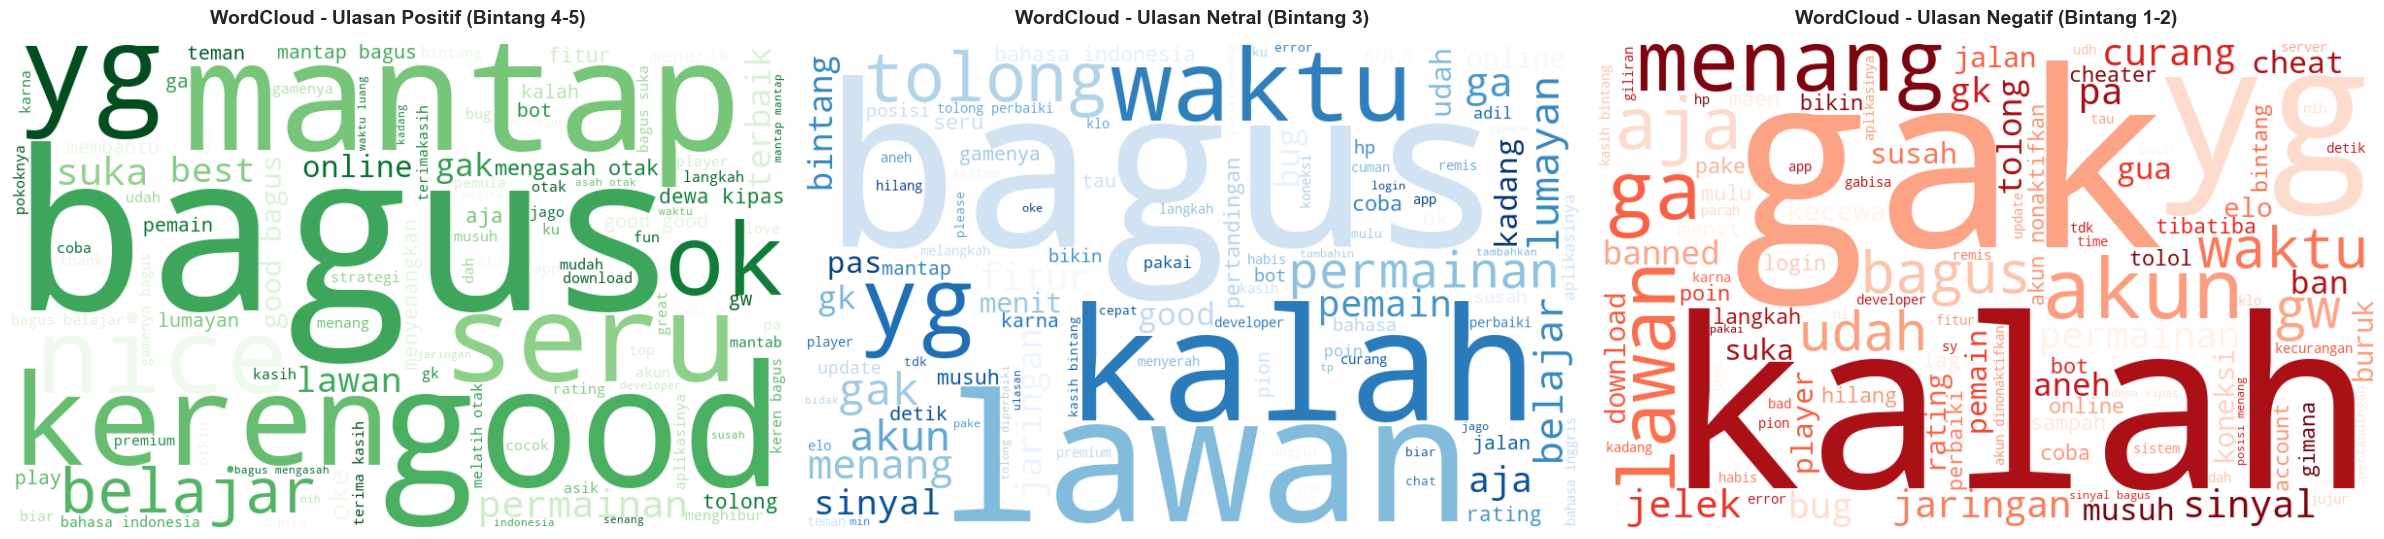

<Figure size 640x480 with 0 Axes>

In [18]:
from wordcloud import WordCloud

# 1. Memisahkan teks ulasan berdasarkan kategori sentimen
teks_positif = " ".join(df[df['rate'] >= 4]['komentar_bersih'].dropna())
teks_netral = " ".join(df[df['rate'] == 3]['komentar_bersih'].dropna())
teks_negatif = " ".join(df[df['rate'] <= 2]['komentar_bersih'].dropna())

# 2. Konfigurasi generator WordCloud
# Kita set background putih dan batasi maksimal 100 kata teratas agar tidak terlalu padat
wc_positif = WordCloud(width=800, height=500, background_color='white', 
                    max_words=100, colormap='Greens').generate(teks_positif)

wc_netral = WordCloud(width=800, height=500, background_color='white', 
                    max_words=100, colormap='Blues').generate(teks_netral)

wc_negatif = WordCloud(width=800, height=500, background_color='white', 
                    max_words=100, colormap='Reds').generate(teks_negatif)

# 3. Setup Kanvas Plot Berdampingan (1 Baris, 3 Kolom)
fig, ax = plt.subplots(1, 3, figsize=(24, 8))

# Tampilkan WordCloud Positif
ax[0].imshow(wc_positif, interpolation='bilinear')
ax[0].set_title('WordCloud - Ulasan Positif (Bintang 4-5)', fontsize=14, fontweight='bold', pad=15)
ax[0].axis('off') # Menghilangkan garis koordinat angka/axis

# Tampilkan WordCloud Netral
ax[1].imshow(wc_netral, interpolation='bilinear')
ax[1].set_title('WordCloud - Ulasan Netral (Bintang 3)', fontsize=14, fontweight='bold', pad=15)
ax[1].axis('off')

# Tampilkan WordCloud Negatif
ax[2].imshow(wc_negatif, interpolation='bilinear')
ax[2].set_title('WordCloud - Ulasan Negatif (Bintang 1-2)', fontsize=14, fontweight='bold', pad=15)
ax[2].axis('off')

plt.tight_layout()
plt.show()
plt.savefig("../reports/figures/eda_wordcloud_sentimen.png", dpi=300)

## 5. Analisis Frasa Dua Kata (Bigram) pada Ulasan Negatif
Jika analisis unigram sebelumnya hanya melihat kata tunggal, Analisis Bigram akan mengekstrak kombinasi dua kata yang muncul secara berurutan. Hal ini sangat penting dalam Natural Language Processing (NLP) untuk mendapatkan konteks keluhan yang lebih spesifik (misalnya menangkap frasa seperti "akun banned" atau "gagal login" dibandingkan hanya kata "banned" atau "login" saja).

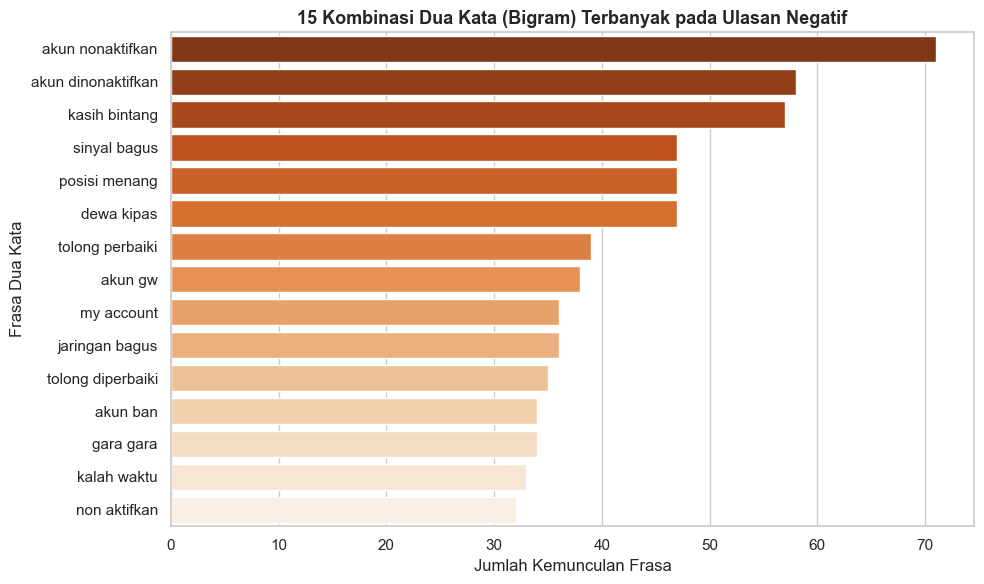

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Ambil komentar negatif
komentar_negatif = df[df['rate'] <= 2]['komentar_bersih'].dropna()

# 2. Inisialisasi CountVectorizer khusus untuk 2 kata (ngram_range=(2,2))
vectorizer_bigram = CountVectorizer(ngram_range=(2, 2), max_features=15)
matriks_bigram = vectorizer_bigram.fit_transform(komentar_negatif)

# 3. Hitung total kemunculan setiap bigram
total_bigram = matriks_bigram.sum(axis=0)
frekuensi_bigram = [(frasa, total_bigram[0, idx]) for frasa, idx in vectorizer_bigram.vocabulary_.items()]
frekuensi_bigram = sorted(frekuensi_bigram, key=lambda x: x[1], reverse=True)

# 4. Ubah ke DataFrame dan Plot
df_bigram = pd.DataFrame(frekuensi_bigram, columns=['Frasa Dua Kata', 'Frekuensi'])

plt.figure(figsize=(10, 6))
sns.barplot(data=df_bigram, x='Frekuensi', y='Frasa Dua Kata', hue='Frasa Dua Kata', palette='Oranges_r', legend=False)
plt.title('15 Kombinasi Dua Kata (Bigram) Terbanyak pada Ulasan Negatif', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Kemunculan Frasa')
plt.tight_layout()

# Simpan grafik
plt.savefig("../reports/figures/eda_bigram_negatif.png", dpi=300, bbox_inches='tight')
plt.show()

## 6. Analisis Hubungan Panjang Ulasan vs Kategori Sentimen
Pada tahap ini, kita akan menguji sebuah hipotesis perilaku pengguna (user behavior): "Apakah pengguna yang memberikan sentimen negatif cenderung menulis komentar yang lebih panjang dan detail untuk meluapkan kekecewaan mereka dibandingkan pengguna yang puas?". Kita akan menghitung jumlah kata asli sebelum dibersihkan dan memvisualisasikan sebarannya menggunakan grafik Boxplot untuk melihat median serta pencilan (outliers) data.

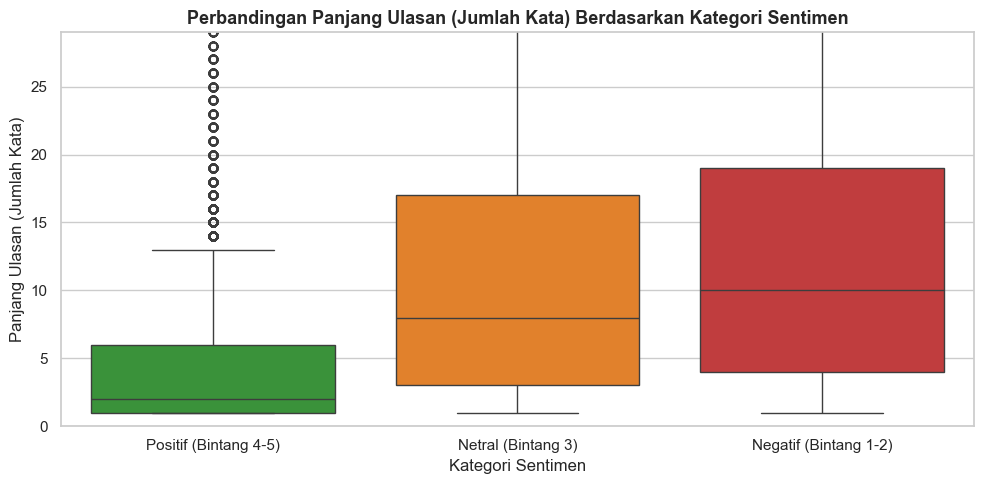

In [20]:
# 1. Hitung jumlah kata pada komentar asli sebelum preprocessing
df['jumlah_kata'] = df['komentar'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
# Menggunakan Boxplot untuk melihat sebaran data dan outlier
sns.boxplot(data=df, x='kategori_sentimen', y='jumlah_kata', palette=kamus_warna, hue='kategori_sentimen')

plt.title('Perbandingan Panjang Ulasan (Jumlah Kata) Berdasarkan Kategori Sentimen', fontsize=13, fontweight='bold')
plt.xlabel('Kategori Sentimen')
plt.ylabel('Panjang Ulasan (Jumlah Kata)')
# Membatasi sumbu Y jika ada ulasan yang terlalu ekstrem panjangnya agar grafik tetap proporsional
plt.ylim(0, df['jumlah_kata'].quantile(0.95)) 
plt.tight_layout()

# Simpan grafik
plt.savefig("../reports/figures/8_panjang_ulasan_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

## 7. Analisis Tren Makro Proporsi Sentimen Tahunan (Skala Dekade)
Untuk melihat performa dan reputasi Chess.com secara helikopter (macro-view) di regional Indonesia dalam kurun waktu 10 tahun terakhir, kita akan membuat Stacked Bar Chart (Grafik Batang Bertumpuk). Grafik ini akan menampilkan persentase kontribusi sentimen (Positif, Netral, Negatif) dari tahun ke tahun secara dinamis sehingga kita bisa mendeteksi kapan titik balik perubahan sentimen massal terjadi.

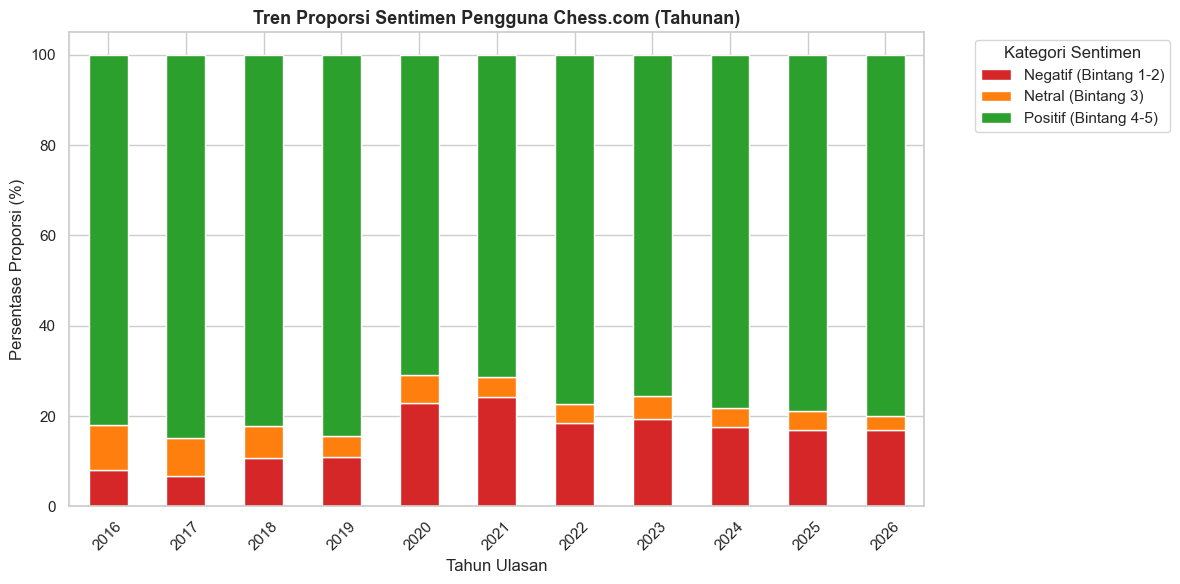

In [21]:
# 1. Membuat tabel silang (Crosstab) antara tahun dan kategori sentimen dalam bentuk persentase
tren_tahunan = pd.crosstab(df['tahun'], df['kategori_sentimen'], normalize='index') * 100

# 2. Plot Stacked Bar Chart
tren_tahunan.plot(kind='bar', stacked=True, figsize=(12, 6), 
                color=['#d62728', '#ff7f0e', '#2ca02c']) # Warna Negatif, Netral, Positif

plt.title('Tren Proporsi Sentimen Pengguna Chess.com (Tahunan)', fontsize=13, fontweight='bold')
plt.xlabel('Tahun Ulasan')
plt.ylabel('Persentase Proporsi (%)')
plt.legend(title='Kategori Sentimen', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

# Simpan grafik
plt.savefig("../reports/figures/eda_tren_makro_tahunan.png", dpi=300, bbox_inches='tight')
plt.show()

## 8. Korelasi Kelompok Topik LDA vs Kategori Sentimen
Sebagai analisis penutup, kita akan melihat bagaimana hubungan antara 3 kelompok topik besar yang ditemukan oleh algoritma LDA (Unsupervised Learning) dengan label sentimen pengguna (Supervised Learning). Ini akan memberikan gambaran komprehensif mengenai fokus masalah pada masing-masing sentimen.

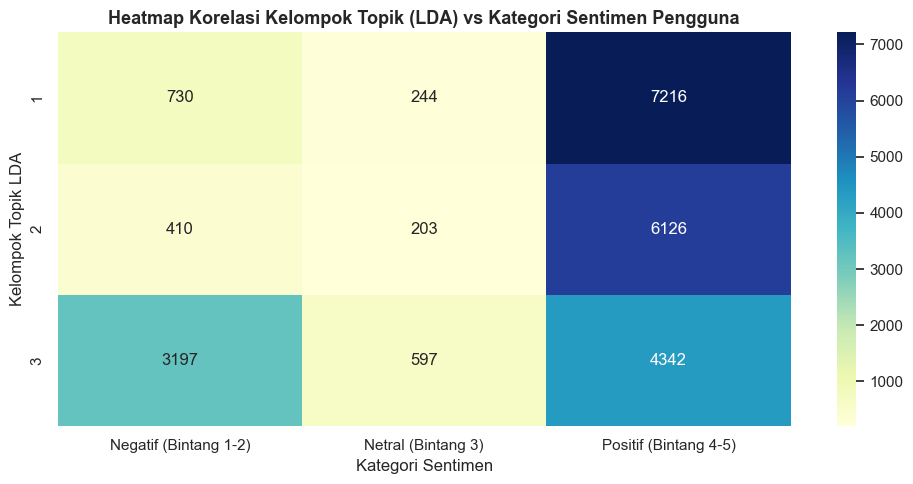

In [22]:
import pickle

# 1. Memuat kembali model LDA dan Vectorizer yang sudah kita latih di Tahap 3
# Pastikan kamu sudah run ulang src/3_topic_modeling.py sebelumnya
with open("../models/rf_tfidf.pkl", "rb") as f: 
    tfidf_for_topic = pickle.load(f)

# Untuk visualisasi ini, kita transformasikan teks ke matriks kata lagi
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

tf_vectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=5000)
tf_matrix = tf_vectorizer.fit_transform(df['komentar_bersih'])

# Latih kilat LDA untuk dipetakan ke dataframe
lda = LatentDirichletAllocation(n_components=3, random_state=42)
distribusi_topik = lda.fit_transform(tf_matrix)

# Ambil indeks topik dengan probabilitas tertinggi untuk setiap baris ulasan
df['topik_dominan'] = distribusi_topik.argmax(axis=1) + 1 # Kita ubah jadi Topik 1, 2, 3

# 2. Buat Tabel Silang (Crosstab) antara Topik Dominan dan Kategori Sentimen
korelasi_topik_sentimen = pd.crosstab(df['topik_dominan'], df['kategori_sentimen'])

# 3. Visualisasikan dengan Heatmap agar estetik
plt.figure(figsize=(10, 5))
sns.heatmap(korelasi_topik_sentimen, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title('Heatmap Korelasi Kelompok Topik (LDA) vs Kategori Sentimen Pengguna', fontsize=13, fontweight='bold')
plt.xlabel('Kategori Sentimen')
plt.ylabel('Kelompok Topik LDA')
plt.tight_layout()

# Simpan grafik
jalur_heatmap = "../reports/figures/10_korelasi_topik_sentimen.png"
plt.savefig(jalur_heatmap, dpi=300, bbox_inches='tight')
plt.show()